In [2]:
import pandas as pd

df = pd.read_csv('/content/Superstore.csv', encoding='latin1')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print("Column Names and Data Types:")
print(df.dtypes)

Column Names and Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [4]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Updated Data Types:")
print(df[['Order Date', 'Ship Date']].dtypes)

Updated Data Types:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [7]:
df.to_csv('/content/Superstore_Cleaned.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [8]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [9]:
print("Correlation Matrix:")

correlation = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

correlation

Correlation Matrix:


,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


In [10]:
print("Outlier Counts:")

for column in ['Sales', 'Quantity', 'Profit']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(column, ":", len(outliers), "outliers")

Outlier Counts:
Sales : 1167 outliers
Quantity : 170 outliers
Profit : 1881 outliers


In [11]:
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

print("Sales and Profit by Category:")
category_analysis

Sales and Profit by Category:


,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


In [12]:
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

print("Sales by Year:")
print(yearly_sales)

Sales by Year:
Order Date
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


In [14]:
yearly_profit = df.groupby(df['Order Date'].dt.year)['Profit'].sum()

print("Profit by Year:")
print(yearly_profit)

Profit by Year:
Order Date
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64


In [15]:
region_analysis = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

print("Sales and Profit by Region:")
print(region_analysis)

Sales and Profit by Region:
               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
Central  501239.8908   39706.3625
South    391721.9050   46749.4303


In [16]:
subcategory_analysis = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

print("Sales and Profit by Sub-Category:")
print(subcategory_analysis)

Sales and Profit by Sub-Category:
                    Sales      Profit
Sub-Category                         
Phones        330007.0540  44515.7306
Chairs        328449.1030  26590.1663
Storage       223843.6080  21278.8264
Tables        206965.5320 -17725.4811
Binders       203412.7330  30221.7633
Machines      189238.6310   3384.7569
Accessories   167380.3180  41936.6357
Copiers       149528.0300  55617.8249
Bookcases     114879.9963  -3472.5560
Appliances    107532.1610  18138.0054
Furnishings    91705.1640  13059.1436
Paper          78479.2060  34053.5693
Supplies       46673.5380  -1189.0995
Art            27118.7920   6527.7870
Envelopes      16476.4020   6964.1767
Labels         12486.3120   5546.2540
Fasteners       3024.2800    949.5182


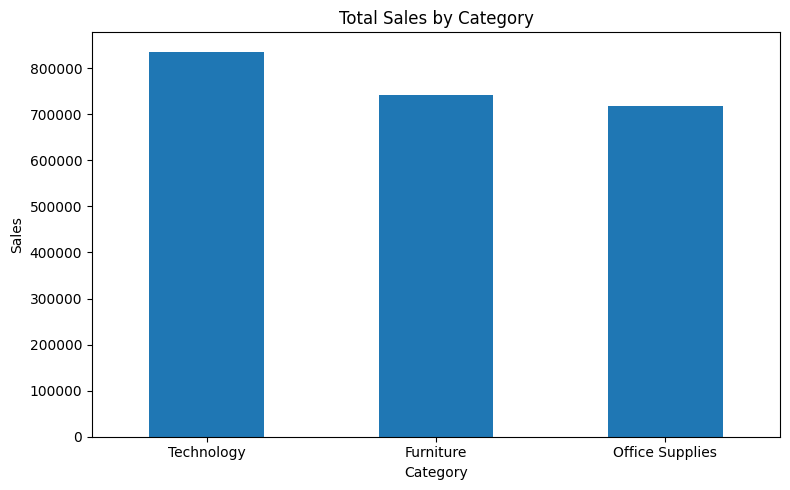

In [17]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

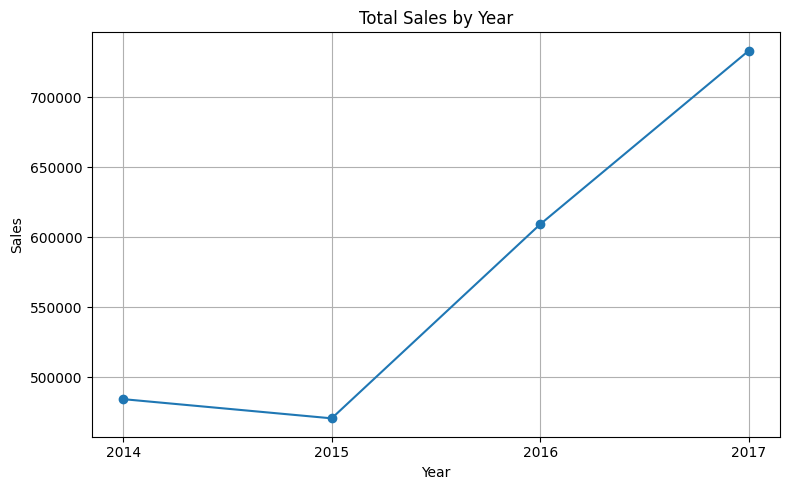

In [18]:
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')

plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.xticks(yearly_sales.index)
plt.grid(True)
plt.tight_layout()
plt.show()

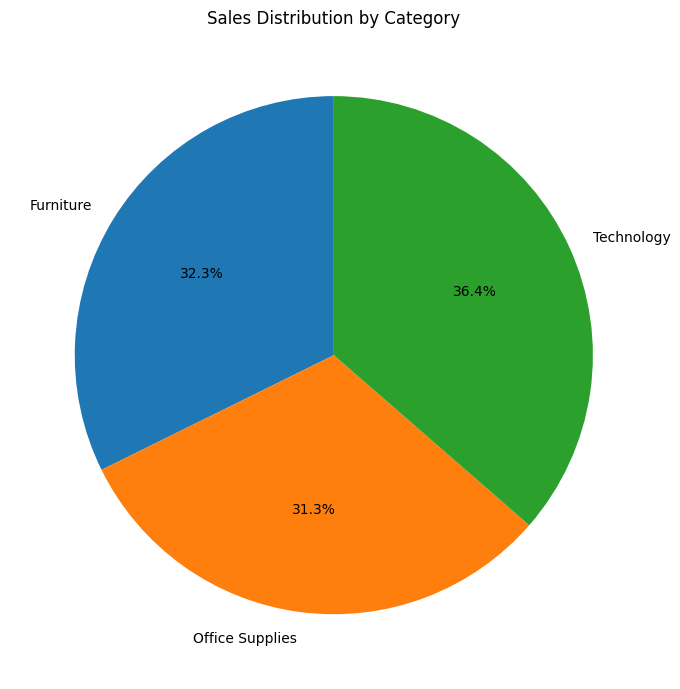

In [19]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(7,7))
plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sales Distribution by Category')
plt.tight_layout()
plt.show()

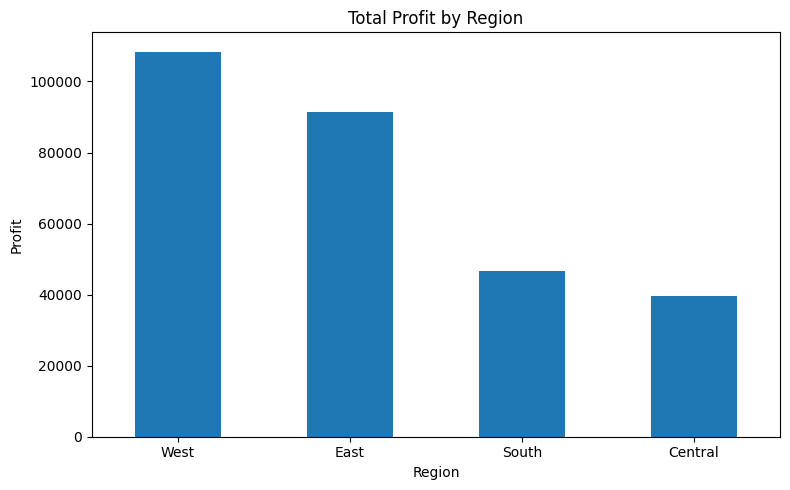

In [20]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

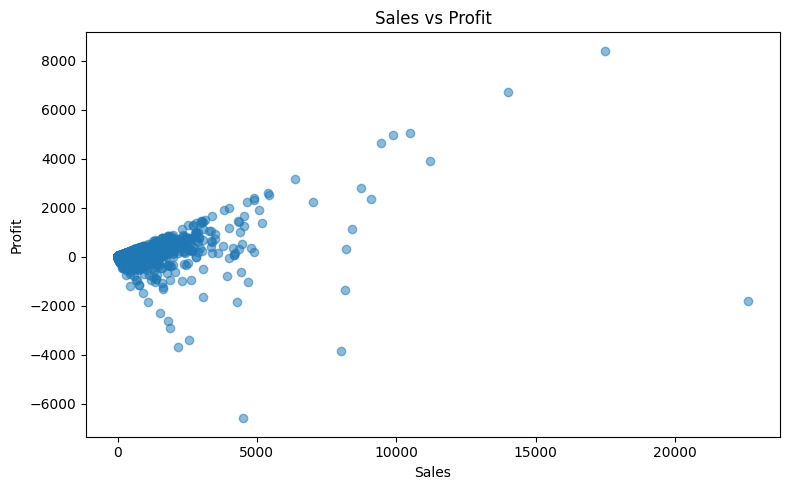

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(df['Sales'], df['Profit'], alpha=0.5)

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()